In [1]:
from lib.contact_settings import *
from lib.geoLib.contact_wheel_rail import wheel, rail
from lib.dynLib.contact_dyn_state import dynamic_state
from lib.normLib.contact_solver import patch_search
from lib.contact_material import material
from lib.normLib.contact_methods import eqv_el_normal_contact, kik_pyo_normal_contact
import matplotlib.pyplot as plt

In [2]:
from calc_routines.determine_static_contact import static_contact

In [3]:
dy = 0.05e-3
# deltays = np.arange(-20e-3, 20e-3 + dy, dy)
deltays = np.array([0])

Wheel = wheel(lr=RIGHT)
Rail = rail(rail_inclination=30, lr=RIGHT)

material_model = material()

contact_model = eqv_el_normal_contact()
# contact_model = kik_pyo_normal_contact()

n_patches = 3

# contact_patches_eq = [eqv_el_normal_contact() for _ in range(n_patches)]
# contact_patches_kik = [kik_pyo_normal_contact() for _ in range(n_patches)]
contact_patches_eq = [
    eqv_el_normal_contact(),
    eqv_el_normal_contact(),
    eqv_el_normal_contact(),
]

contact_patches = [
    kik_pyo_normal_contact(),
    kik_pyo_normal_contact(),
    kik_pyo_normal_contact(),
]

In [4]:
patches_per_deltays_eq, result_state_pressure_eq = static_contact(
    deltays, Wheel, Rail, contact_patches_eq, material_model
)

100%|██████████| 1/1 [00:00<00:00, 19.19it/s]


In [5]:
from lib.tanLib.tangent_methods import *

fastsim_patch = fastsim()
creep = tangent_creepage(nu_x=0.001, nu_y=0.001, phi=0.2)
contact_patches_eq[0].normal_force = 75000
contact_patches_eq[0].semi_axis_a = 10*10**-3
contact_patches_eq[0].semi_axis_b = 5*10**-3

new_state_0 = dynamic_state(state_v_x=100/3.6)
calc_tangent_force(fastsim_patch, contact_patches_eq[0], material_model, creep, new_state_0)

In [6]:
attributes = vars(contact_patches_eq[0])

for attr, value in attributes.items():
    print(f"{attr}: {value}")

approach: [5.87243588e-05]
normal_force: 75000
Q_force: [49999.99999996]
Y_force: [740.09906566]
centroid_wheel: [0.75862058]
centroid_rail: [0.75862011]
contact_angle: 0
semi_axis_a: 0.01
semi_axis_b: 0.005
A_Hertz: [1.98550097]
B_Hertz: [1.75173899]
teta_Hertz: [86.41384443]
ratio_Hertz: [0.71480625]


In [7]:
print(fastsim_patch.F_x, fastsim_patch.F_y)
print(fastsim_patch.s_out)

-12697.583769529254 -24216.85505434243
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


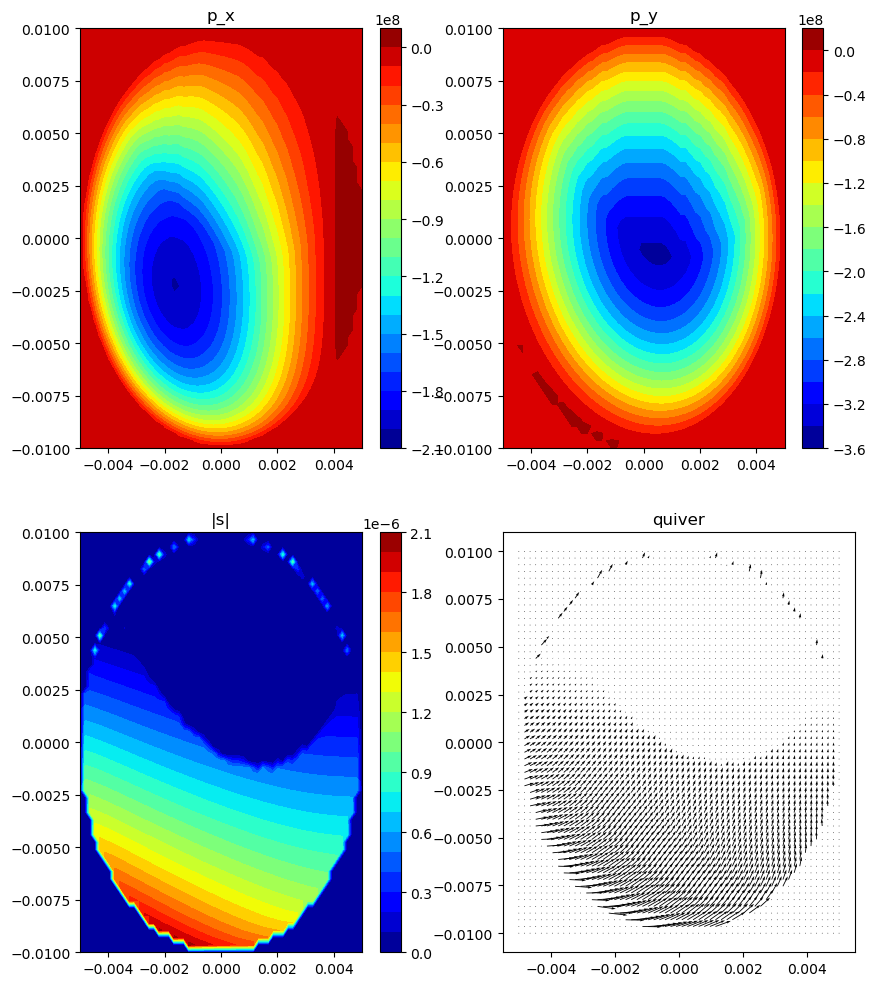

In [8]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 12))
c = ax[0,0].contourf(fastsim_patch.yy, fastsim_patch.xx, fastsim_patch.p_x, levels=20, cmap='jet')
ax[0,0].set_title('p_x')
fig.colorbar(c, ax=ax[0,0])

c = ax[0,1].contourf(fastsim_patch.yy, fastsim_patch.xx, fastsim_patch.p_y, levels=20, cmap='jet')
ax[0,1].set_title('p_y')
fig.colorbar(c, ax=ax[0,1])

c = ax[1,0].contourf(fastsim_patch.yy, fastsim_patch.xx, fastsim_patch.s_out, levels=20, cmap='jet')
ax[1,0].set_title('|s|')
fig.colorbar(c, ax=ax[1,0])

c = ax[1,1].quiver(fastsim_patch.yy, fastsim_patch.xx, fastsim_patch.s_x, fastsim_patch.s_y, scale=3)
ax[1,1].set_title('quiver')

plt.show()